# Lecture 7 (FunML): Plots & Graphs Notebook

This notebook generates figures that align with **Lecture 7: Linear Regression** and saves images to `img/lecture7/` for inclusion in LaTeX.

In [19]:
from pathlib import Path

BASE_DIR = Path.cwd()          # current path (e.g., /content)
OUT_DIR = BASE_DIR / "img/lecture7"     # /content/img

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Saving figures to:", OUT_DIR.resolve())

Saving figures to: /content/img/lecture7


## 1) Better Life Index-style example (GDP per capita vs Life Satisfaction)
We fit a simple linear regression and plot the scatter + fitted line, then residuals.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_CANDIDATES = ["oecd_bli.csv", "oecd_bli_2015.csv", "better_life_index.csv"]
df = None
for fp in CSV_CANDIDATES:
    if os.path.exists(fp):
        df = pd.read_csv(fp)
        print("Loaded:", fp, "| columns:", list(df.columns))
        break

# Built-in toy data if you don't have the CSV locally
if df is None:
    df = pd.DataFrame({
        "country": ["A","B","C","D","E","F","G","H","I","J"],
        "gdp_per_capita": [18000,22000,26000,30000,34000,38000,42000,46000,52000,60000],
        "life_satisfaction": [5.1,5.4,5.7,6.0,6.2,6.4,6.7,6.8,7.1,7.4],
    })
    print("Using built-in toy dataset:", df.shape)

cols = {c.lower().strip(): c for c in df.columns}
gdp_col = cols.get("gdp_per_capita") or cols.get("gdp per capita") or cols.get("gdp") or cols.get("gdppercapita")
ls_col  = cols.get("life_satisfaction") or cols.get("life satisfaction") or cols.get("life") or cols.get("lifesatisfaction")
if gdp_col is None or ls_col is None:
    raise ValueError("Need GDP + Life Satisfaction columns in your CSV.")

X = df[gdp_col].to_numpy().reshape(-1, 1).astype(float)
y = df[ls_col].to_numpy().astype(float)

rng = np.random.default_rng(7)
idx = np.arange(len(X)); rng.shuffle(idx)
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
print("Train n =", len(train_idx), "| Test n =", len(test_idx))


Using built-in toy dataset: (10, 3)
Train n = 8 | Test n = 2


In [21]:
# Normal equation (with pseudoinverse for stability)
Xtilde = np.c_[np.ones((len(X_train), 1)), X_train]
theta_hat = np.linalg.pinv(Xtilde.T @ Xtilde) @ (Xtilde.T @ y_train)
theta0, theta1 = float(theta_hat[0]), float(theta_hat[1])
print("theta0 =", theta0, "| theta1 =", theta1)

def predict(x):
    x = np.asarray(x).reshape(-1, 1)
    return theta0 + theta1 * x[:, 0]

yhat_train = predict(X_train)
yhat_test  = predict(X_test)
print("MSE(train) =", float(np.mean((yhat_train - y_train)**2)))
print("MSE(test)  =", float(np.mean((yhat_test  - y_test )**2)))


theta0 = 4.1480474547076405 | theta1 = 5.8576371713644446e-05
MSE(train) = 0.005543746910528944
MSE(test)  = 0.034826506964781005


Saved: /content/img/lecture7/bli_scatter_fit.png


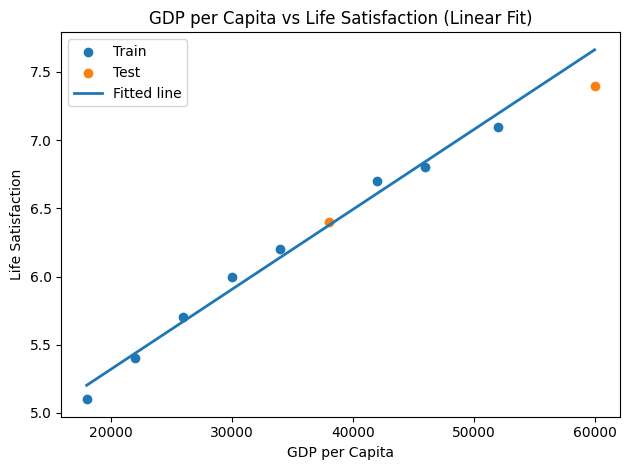

In [22]:
# Figure: scatter + fitted line
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_grid = predict(x_grid)

plt.figure()
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
plt.plot(x_grid, y_grid, linewidth=2, label="Fitted line")
plt.xlabel("GDP per Capita"); plt.ylabel("Life Satisfaction")
plt.title("GDP per Capita vs Life Satisfaction (Linear Fit)")
plt.legend(); plt.tight_layout()

out_fp = OUT_DIR / "bli_scatter_fit.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()


Saved: /content/img/lecture7/bli_residuals_scatter.png


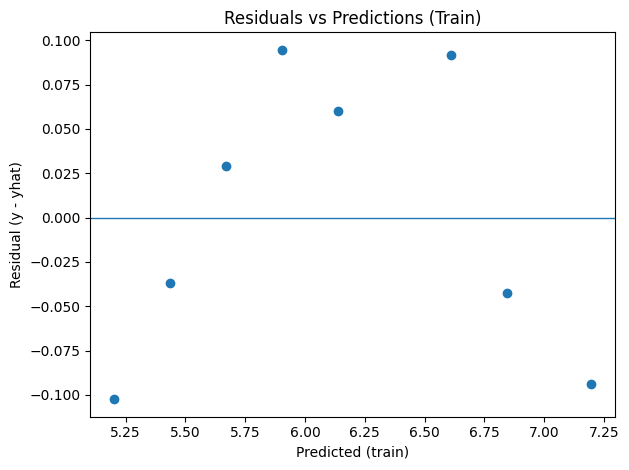

Saved: /content/img/lecture7/bli_residuals_hist.png


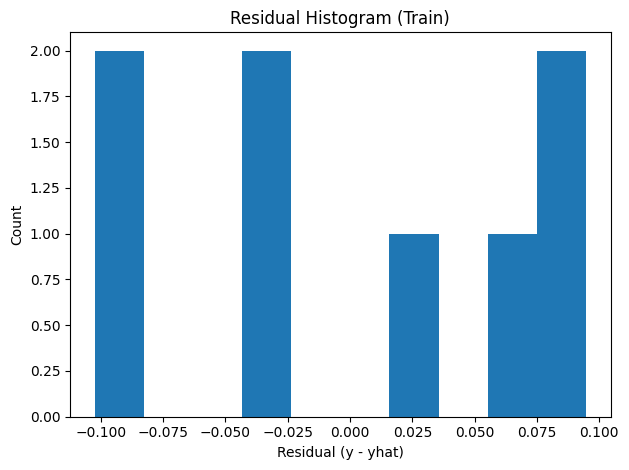

In [23]:
# Figures: residuals
residuals = y_train - yhat_train

plt.figure()
plt.scatter(yhat_train, residuals)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted (train)"); plt.ylabel("Residual (y - yhat)")
plt.title("Residuals vs Predictions (Train)")
plt.tight_layout()
out_fp = OUT_DIR / "bli_residuals_scatter.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()

plt.figure()
plt.hist(residuals, bins=10)
plt.xlabel("Residual (y - yhat)"); plt.ylabel("Count")
plt.title("Residual Histogram (Train)")
plt.tight_layout()
out_fp = OUT_DIR / "bli_residuals_hist.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()


## 2) Least Squares Loss Geometry
Contour plot of the MSE over $(\theta_0,\theta_1)$ with the optimum marked.

Saved: /content/img/lecture7/mse_contour_theta0_theta1.png


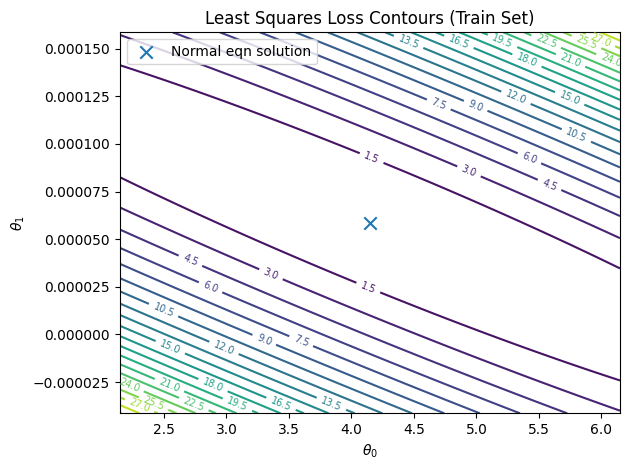

In [24]:
t0_vals = np.linspace(theta0 - 2.0, theta0 + 2.0, 150)
t1_vals = np.linspace(theta1 - 0.0001, theta1 + 0.0001, 150)

T0, T1 = np.meshgrid(t0_vals, t1_vals)
Yhat_grid = T0[..., None] + T1[..., None] * X_train.reshape(1, 1, -1)
MSE_grid = np.mean((Yhat_grid - y_train.reshape(1, 1, -1))**2, axis=-1)

plt.figure()
cs = plt.contour(T0, T1, MSE_grid, levels=25)
plt.clabel(cs, inline=True, fontsize=7)
plt.scatter([theta0], [theta1], marker="x", s=80, label="Normal eqn solution")
plt.xlabel(r"$\theta_0$"); plt.ylabel(r"$\theta_1$")
plt.title("Least Squares Loss Contours (Train Set)")
plt.legend(); plt.tight_layout()

out_fp = OUT_DIR / "mse_contour_theta0_theta1.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()


## 3) ROC + Precision–Recall Curves
Simulated scores to generate ROC/AUC and PR curves (matches the evaluation section of the lecture).

Saved: /content/img/lecture7/roc_curve.png


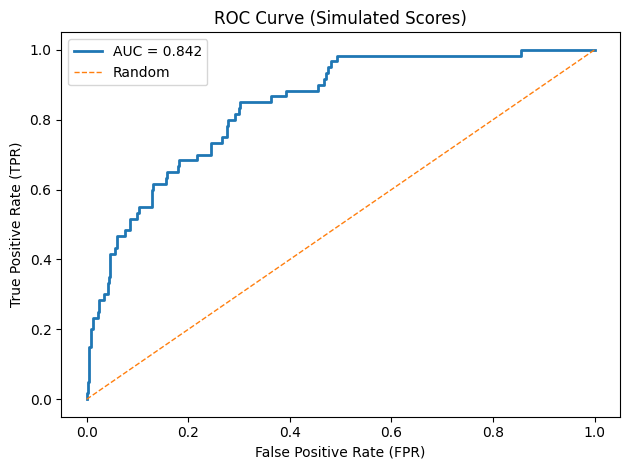

Saved: /content/img/lecture7/pr_curve.png


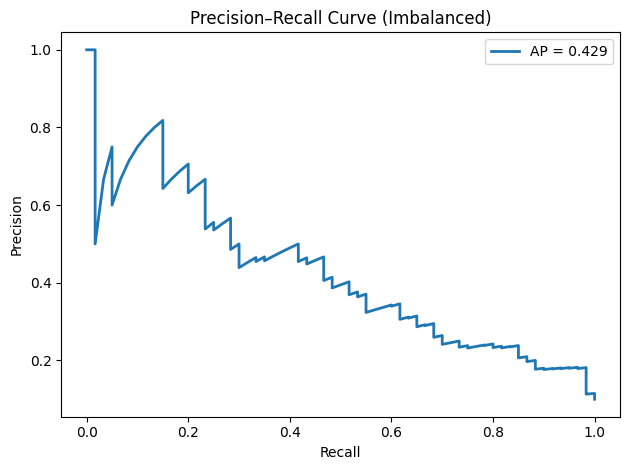

In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n_pos, n_neg = 60, 540
y_true = np.r_[np.ones(n_pos), np.zeros(n_neg)]
scores_pos = rng.normal(loc=1.0, scale=0.8, size=n_pos)
scores_neg = rng.normal(loc=0.0, scale=0.8, size=n_neg)
y_score = np.r_[scores_pos, scores_neg]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate (FPR)"); plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Simulated Scores)")
plt.legend(); plt.tight_layout()
out_fp = OUT_DIR / "roc_curve.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()

prec, rec, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure()
plt.plot(rec, prec, linewidth=2, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Imbalanced)")
plt.legend(); plt.tight_layout()
out_fp = OUT_DIR / "pr_curve.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()


## 4) Regularization: Ridge vs Lasso coefficient paths
Shows how coefficients shrink (Ridge) and become sparse (Lasso) as $\lambda$ increases.

Saved: /content/img/lecture7/ridge_paths.png


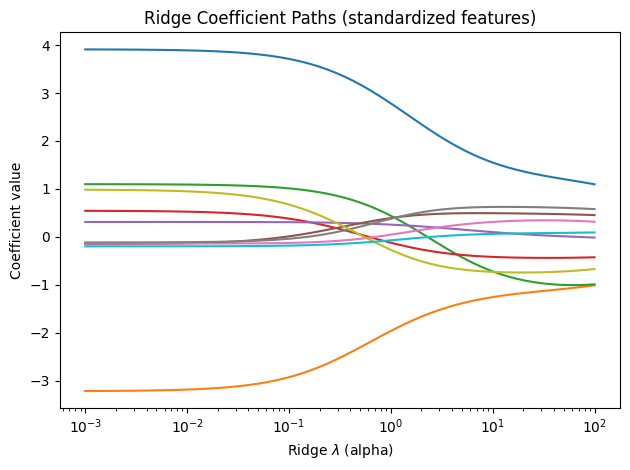

Saved: /content/img/lecture7/lasso_paths.png


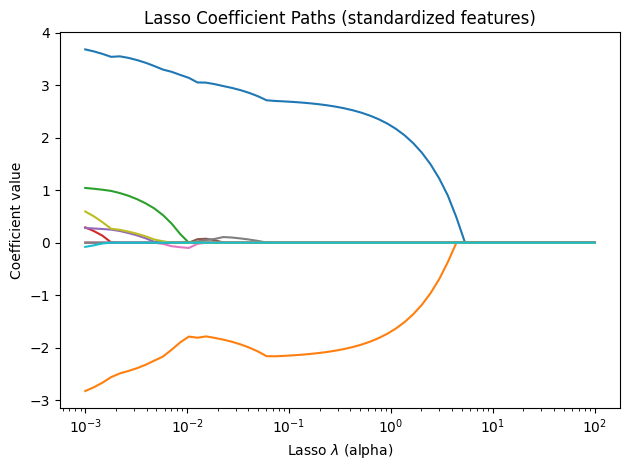

In [26]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
n, p = 200, 10
z = rng.normal(size=(n, 2))
X_reg = np.hstack([z @ rng.normal(size=(2, 1)) + 0.1 * rng.normal(size=(n, 1)) for _ in range(p)])
true_beta = np.zeros(p); true_beta[[0,1,2]] = [2.5, -1.5, 1.0]
y_reg = X_reg @ true_beta + 0.5 * rng.normal(size=n)

alphas = np.logspace(-3, 2, 60)
ridge_coefs, lasso_coefs = [], []

for a in alphas:
    ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=a))])
    lasso = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=a, max_iter=20000))])
    ridge.fit(X_reg, y_reg); lasso.fit(X_reg, y_reg)
    ridge_coefs.append(ridge.named_steps["model"].coef_)
    lasso_coefs.append(lasso.named_steps["model"].coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

plt.figure()
for j in range(p):
    plt.plot(alphas, ridge_coefs[:, j])
plt.xscale("log")
plt.xlabel(r"Ridge $\lambda$ (alpha)"); plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Paths (standardized features)")
plt.tight_layout()
out_fp = OUT_DIR / "ridge_paths.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()

plt.figure()
for j in range(p):
    plt.plot(alphas, lasso_coefs[:, j])
plt.xscale("log")
plt.xlabel(r"Lasso $\lambda$ (alpha)"); plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Paths (standardized features)")
plt.tight_layout()
out_fp = OUT_DIR / "lasso_paths.png"
plt.savefig(out_fp, dpi=200)
print("Saved:", out_fp)
plt.show()


## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

In [ ]:
# INTERACTIVE_WIDGET_SECTION\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport ipywidgets as widgets\n\ndef _interactive_demo(freq=1.0, amp=1.0, phase=0.0):\n    x=np.linspace(-10,10,500)\n    y=amp*np.sin(freq*x+phase)\n    plt.figure(figsize=(8,4))\n    plt.plot(x,y,lw=2)\n    plt.grid(True)\n    plt.title('Interactive Demo Panel')\n    plt.show()\n\nwidgets.interact(_interactive_demo,\n    freq=widgets.FloatSlider(value=1.0,min=0.1,max=5.0,step=0.1),\n    amp=widgets.FloatSlider(value=1.0,min=0.1,max=3.0,step=0.1),\n    phase=widgets.FloatSlider(value=0.0,min=-3.14,max=3.14,step=0.1))\n